In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [1]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'graphviz'

In [ ]:
import os
from pathlib import Path

# Create results directory
result_dir = Path('result')
result_dir.mkdir(exist_ok=True)
(result_dir / 'plots').mkdir(exist_ok=True)
(result_dir / 'metrics').mkdir(exist_ok=True)

print(f"Result directory created at: {result_dir.absolute()}")

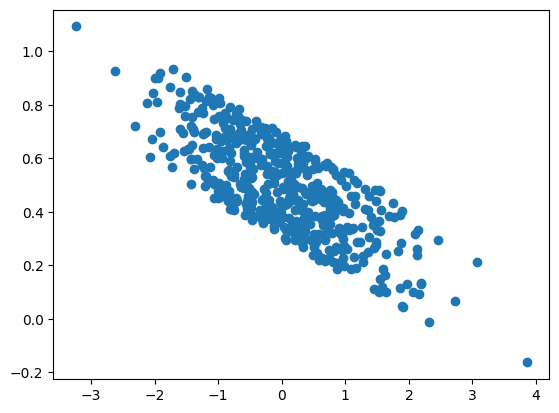

In [4]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [ ]:
import glob
import json
from model.linear_model import LinearModel

# Define learning rates and dataset files
learning_rates = [0.1, 0.01, 0.001]
dataset_files = sorted(glob.glob('data/linear_data/linear_data_*.npz'))

# Store all results for summary table
all_results = {}

In [ ]:
# Loop through each dataset
for dataset_path in dataset_files:
    dataset_name = Path(dataset_path).stem  # e.g., 'linear_data_A'
    
    # Load dataset
    loaded_data = np.load(dataset_path)
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']
    
    size = X.shape[0]
    dim = X.shape[1] - 1
    
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name} (size={size}, dim={dim})")
    print(f"{'='*60}")
    
    all_results[dataset_name] = {}

    # Train the model

    # Loop through each learning rate
    for lr in learning_rates:
        # Set seed for reproducibility
        seed = 42
        np.random.seed(seed)
        
        # Split data
        X_train, y_train, X_val, y_val = get_train_val(X, y)
        
        # Create and train model
        model = LinearModel(dim, True, MSE, MSE_grad)
        model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

        # Get predictions
        y_val_pred = model.predict(X_val)
        
        # Evaluate
        title = f'{dataset_name} - Learning Rate: {lr}'
        metrics = evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title=title)
        
        # Save metrics
        all_results[dataset_name][f'lr_{lr}'] = metrics
        
        # Save loss curves plot
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(range(len(model.train_losses)), model.train_losses, 'o-', color='r', label='Training loss', markersize=2)
        ax.plot(range(len(model.val_losses)), model.val_losses, 'o-', color='g', label='Validation loss', markersize=2)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_title(f'Learning Curves: {dataset_name} (LR={lr})')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        plot_filename = f'result/plots/{dataset_name}_lr_{lr}_loss_curve.png'
        fig.savefig(plot_filename, dpi=100, bbox_inches='tight')
        print(f"  → Saved plot: {plot_filename}")
        plt.close(fig)
        
        # Save prediction plot
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(X_val[:, 1], y_val, alpha=0.5, label='Actual')
        ax.plot(X_val[:, 1], y_val_pred, 'r-', label='Prediction', linewidth=2)
        ax.set_xlabel('Feature')
        ax.set_ylabel('Target')
        ax.set_title(f'Predictions: {dataset_name} (LR={lr})')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        pred_filename = f'result/plots/{dataset_name}_lr_{lr}_predictions.png'
        fig.savefig(pred_filename, dpi=100, bbox_inches='tight')
        print(f"  → Saved plot: {pred_filename}")
        plt.close(fig)

X size : (1600, 2), y size : (1600,)


In [ ]:
# Save summary metrics as JSON
summary_file = 'result/metrics/summary_metrics.json'
with open(summary_file, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n✓ Summary metrics saved to: {summary_file}")

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
for dataset_name, lr_results in all_results.items():
    print(f"\n{dataset_name}:")
    for lr_key, metrics in lr_results.items():
        lr_val = lr_key.replace('lr_', '')
        print(f"  LR {lr_val}: MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R²={metrics['R-squared']:.4f}")